# 반드시 pandas import
# matplotlib (매트플롯립도 반드시 import)

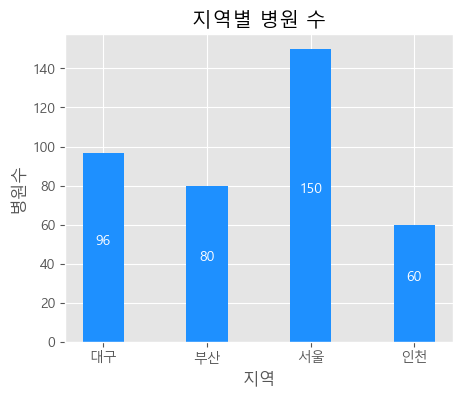

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역" : ["서울", "부산", "대구"],
    "총인구" : [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역" : ["서울", "부산", "인천"],
    "병원수" : [150, 80, 60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2가 합집합이 된다.
merged = pd.merge(df1, df2, on = "지역", how = "outer")
merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와 총인구의 평균으로 정의한다.
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())
merged

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x,y)
# -------------------------------------

# 차트 배경 + 색상 자동으로 그리드에 빨간색으로 지정
plt.style.use('ggplot')

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (5,4))

# -------------------------------------
# x축 : 지역 , y축 : 병원수
# 세로막대 기본 넓이 -> width 0.8
# -------------------------------------
bars = plt.bar(merged["지역"], merged["병원수"], width=0.4, color = 'dodgerblue')

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")

# 세로막대 각각의 데이터 레이블값 출력하는 방법
for bar in bars:
    height = bar.get_height() # 막대 높이 추출하는 함수 ex) 대구 : 96
    # bar.get_x() => 막대 그래프 넓이 시작점 추출
    # bar.get_width() => 막대 그래프 넓이 추출
    plt.text(bar.get_x() + bar.get_width() / 2, height / 2, f'{int(height)}', ha='center',va='bottom', color = '#fff')

# 반드시 저장이 먼저
plt.savefig('hospital_chart.png',dpi=300)

# 그래프 출력
plt.show()
